# Proyecto Final Data Mining
## Análisis de Ventas de Videojuegos
### Dataset: vgsales.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

In [7]:
df = pd.read_csv('/Users/loren/Documents/GitHub/Proyecto-1---Data-mining/data/vgsales.csv', sep=',')
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [8]:
print("Filas y columnas:", df.shape)
print("\nTipos de variables:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())

Filas y columnas: (16598, 11)

Tipos de variables:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Valores nulos por columna:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


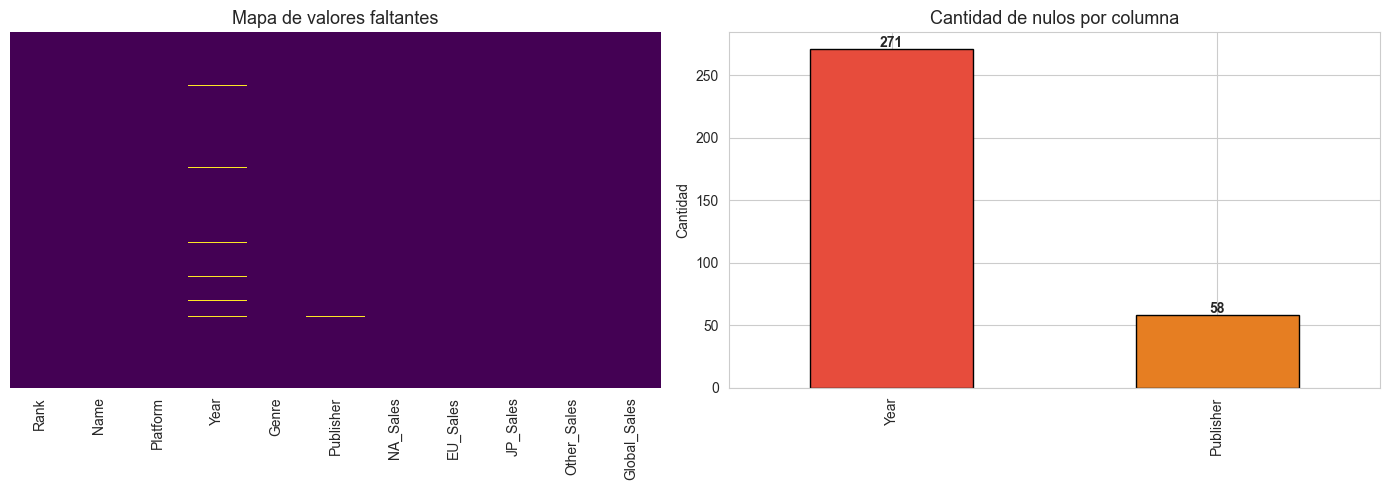

In [ ]:
import missingno as msno
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=False, ax=axes[0], 
            yticklabels=False, cmap='viridis')
axes[0].set_title('Mapa de valores faltantes', fontsize=13)
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
nulos.plot(kind='bar', ax=axes[1], color=['#E74C3C', '#E67E22'], edgecolor='black')
axes[1].set_title('Cantidad de nulos por columna', fontsize=13)
axes[1].set_ylabel('Cantidad')
for i, v in enumerate(nulos):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
print("Estadísticas básicas:")
df.describe()

Estadísticas básicas:


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## 1. Exploración Inicial

El dataset contiene **16,598 registros y 11 variables**: 4 categóricas 
(Name, Platform, Genre, Publisher) y 7 numéricas (Year, NA_Sales, EU_Sales, 
JP_Sales, Other_Sales, Global_Sales, Rank).

**Valores nulos detectados:**
- Year: 271 nulos (1.6%)
- Publisher: 58 nulos (0.3%)

**Observaciones iniciales:**
- Las ventas globales tienen una mediana de 0.17M pero un máximo de 82.74M,
  lo que indica una distribución muy sesgada hacia la derecha.
- Los juegos cubren el período 1980–2020.
- Los nulos serán tratados en la sección de imputación.